In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [2]:
# Import required libraries
import pandas as pd
from sqlalchemy import create_engine
# Create connection engine
# -----------------------------
engine = create_engine(f'postgresql+psycopg2://{'postgres'}:{12345678}@{'localhost'}:{'5432'}/{'churn_analysis'}')

In [3]:
# ============================================
# Load cleaned tables from PostgreSQL into Pandas
# ============================================

# Customers table
customers_clean = pd.read_sql("""SELECT * FROM customers_clean""", engine)  # Load customers_clean
print("Customers Table Loaded:", customers_clean.shape)

# Orders table
orders_clean = pd.read_sql("""SELECT * FROM orders_clean""", engine)        # Load orders_clean
print("Orders Table Loaded:", orders_clean.shape)

# Payments table
payments_clean = pd.read_sql("""SELECT * FROM payments_clean""", engine)    # Load payments_clean
print("Payments Table Loaded:", payments_clean.shape)

# Reviews table
reviews_clean = pd.read_sql("""SELECT * FROM reviews_clean""", engine)      # Load reviews_clean
print("Reviews Table Loaded:", reviews_clean.shape)

Customers Table Loaded: (683234, 3)
Orders Table Loaded: (1000000, 4)
Payments Table Loaded: (1000000, 3)
Reviews Table Loaded: (1000000, 4)


In [4]:
# Run a SQL query and return result as Pandas DataFrame:
def run(query):
    return pd.read_sql(query, engine)

In [5]:
# ============================================
# Check data types of all cleaned tables
# ============================================

print(customers_clean.dtypes) 
print(orders_clean.dtypes)     
print(payments_clean.dtypes)    
print(reviews_clean.dtypes)     

customer_id        int64
customer_city     object
customer_state    object
dtype: object
order_id                     int64
customer_id                  int64
order_purchase_timestamp    object
order_status                object
dtype: object
order_id          int64
payment_type     object
payment_value     int64
dtype: object
review_id         int64
order_id          int64
review_score    float64
review_date      object
dtype: object


In [24]:
# Fixing Data Type of Date Columns: 
reviews_clean['review_date'] = pd.to_datetime(reviews_clean['review_date'])
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])

In [7]:
# ============================================
# 4 Sample Rows from Each Tables:
# ============================================

print(customers_clean.head(4))
print(orders_clean.head(4))
print(payments_clean.head(4))
print(reviews_clean.head(4))

   customer_id customer_city customer_state
0        11351         Delhi             TN
1        32423     Bangalore             DL
2        30497       Chennai             KA
3        30309        Mumbai        Unknown
   order_id  customer_id order_purchase_timestamp order_status
0     16386        46554               2023-11-17    delivered
1      1975        23092               2023-07-29    delivered
2     21341        14695               2023-05-13    cancelled
3     28069        25429               2023-07-07    delivered
   order_id payment_type  payment_value
0     81792          UPI           4208
1     57447          COD            440
2     91758      Unknown           4432
3     33471          COD           1575
   review_id  order_id  review_score review_date
0      39994     39994           3.0  2023-07-09
1      15885     15885           5.0  2023-03-15
2       1152      1152           3.0  2022-12-14
3      11694     11694           2.0  2023-03-19


In [8]:
# Customer Churn Analysis – Business Questions

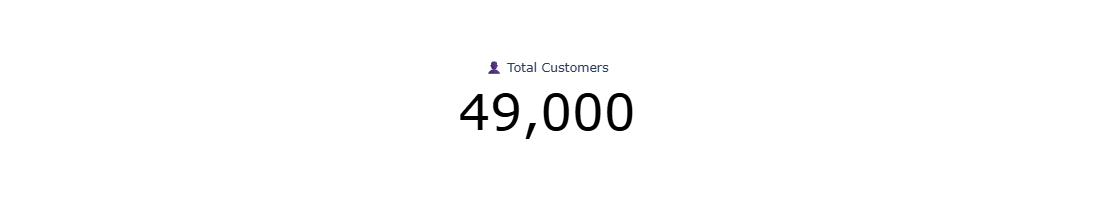

In [6]:
# 1. Core Churn Metrics.

# Total number of customers: 
Total_Customer = run("""select count(distinct customer_id) as Total_Customers
                 from customers_clean""")


import plotly.graph_objects as go

# Correct value
total_customers_value = Total_Customer['total_customers'][0]

fig = go.Figure(go.Indicator(
    mode = "number",
    value = total_customers_value,
    title = {"text": "👤 Total Customers"},
    number = {"font": {"size": 50, "color": "black"},
              "valueformat": ",d"}  # comma as thousands separator
))

fig.update_layout(height=200)
fig.show()

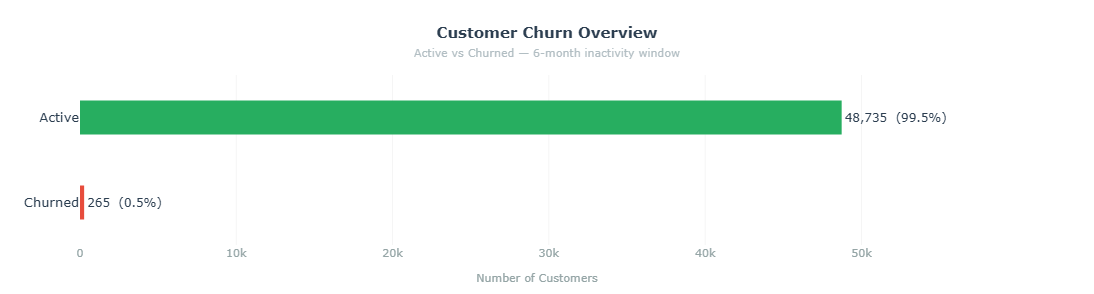

In [51]:
#  1. Core Churn Metrics

 # Number of active vs churned customers:

churn_data = run(""" with max_date_table as 
   (select max(order_purchase_timestamp) as max_date
    from orders_clean ),

    last_order_table as (select c.customer_id, max(o.order_purchase_timestamp) as last_order
    from orders_clean o
    join customers_clean c
    on c.customer_id = o.customer_id 
    group by c.customer_id )

    select 
       case     
       when last_order is null or
       last_order < ((select max_date from max_date_table) - interval '180 days')
       then 'Churned'
       else 'Active'
       end as Churn_Status, 
       count (*) as customer_count
       from last_order_table 
       group by Churn_Status""")

import plotly.graph_objects as go

churn_data.columns = ['churn_status', 'customer_count']
churn_data = churn_data.sort_values(by='customer_count', ascending=True)

total = churn_data['customer_count'].sum()
churn_data['pct'] = (churn_data['customer_count'] / total * 100).round(1)

colors = {'Churned': '#e74c3c', 'Active': '#27ae60'}

fig = go.Figure()

fig.add_trace(go.Bar(
    y=churn_data['churn_status'],
    x=churn_data['customer_count'],
    orientation='h',
    marker=dict(
        color=[colors.get(s, '#95a5a6') for s in churn_data['churn_status']],
        line=dict(width=0)
    ),
    width=0.4,
    text=[f"{v:,}  ({p}%)" for v, p in zip(churn_data['customer_count'], churn_data['pct'])],
    textposition='outside',
    textfont=dict(size=12, color='#2c3e50'),
    hovertemplate="<b>%{y}</b><br>Customers: <b>%{x:,}</b><extra></extra>"
))

fig.update_layout(
    title=dict(
        text="<b>Customer Churn Overview</b><br><span style='font-size:11px;color:#b2bec3'>Active vs Churned — 6-month inactivity window</span>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Number of Customers', font=dict(size=11, color='#95a5a6')),
        tickfont=dict(size=11, color='#95a5a6'),
        gridcolor='#f5f5f5',
        zeroline=False,
        range=[0, churn_data['customer_count'].max() * 1.2]
    ),
    yaxis=dict(
        tickfont=dict(size=13, color='#2c3e50'),
        showgrid=False,
        zeroline=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=280,
    margin=dict(t=75, b=45, l=80, r=100)
)

fig.show()

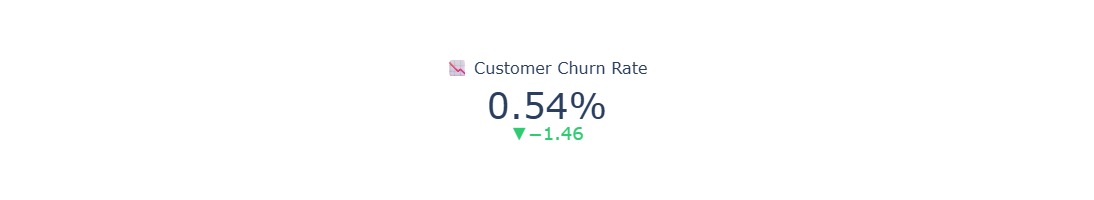

In [85]:
# Overall churn rate (%): 
df = run(""" with max_date_table as (
    select max(order_purchase_timestamp) as max_date 
    from orders_clean
),
    last_order_table as (select c.customer_id, max(o.order_purchase_timestamp) as last_order
    from orders_clean o 
    join customers_clean c 
    on c.customer_id = o.customer_id 
    group by c.customer_id
    ),

    churn_flag as (select case
    when last_order is null 
    or last_order < ((select max_date from max_date_table) - interval '180 days')
    then 1
    else 0
    end as is_churn from last_order_table)

   select round(100.00 * sum(is_churn) /count(*),2) as churn_rate_percentage
   from churn_flag """)

import plotly.graph_objects as go

churn_value = df['churn_rate_percentage'][0]

fig = go.Figure(go.Indicator(
    
    mode="number+delta",
    
    value=churn_value,
    
    # 🔥 MAIN NUMBER (clean & bold)
    number={
        'suffix': "%",
        'font': {'size': 36}
    },
    
    # 🔥 SMALL CONTEXT (optional benchmark)
    delta={
        'reference': 2,   # benchmark (you can adjust)
        'relative': False,
        'increasing': {'color': "#e74c3c"},
        'decreasing': {'color': "#2ecc71"}
    },
    
    # 🔥 PROFESSIONAL TITLE + EMOJI
    title={
        'text': "📉 Customer Churn Rate",
        'font': {'size': 16}
    }
))

# 🔥 CLEAN LAYOUT (compact size)
fig.update_layout(

    height=200,
    margin=dict(t=50, b=20, l=20, r=20),
    paper_bgcolor="white"
)

fig.show()

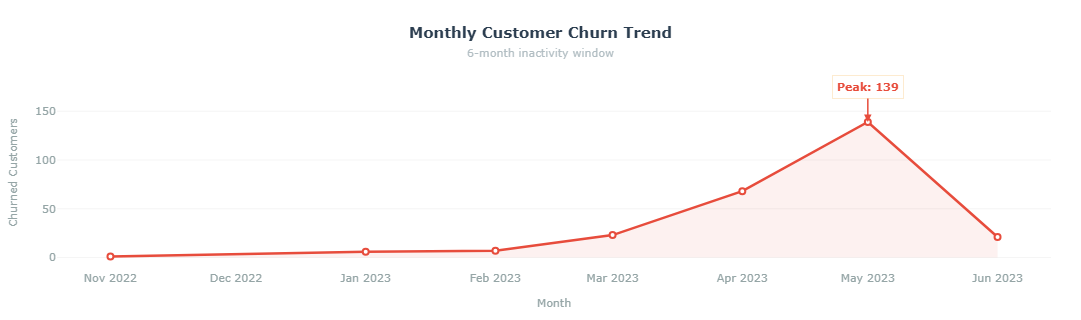

In [41]:
# Monthly churn trend over time: 

df = run(""" with max_date_table as (
      select max(order_purchase_timestamp) as max_date from orders_clean), 
      
       last_date_table as ( 
           select c.customer_id, max(order_purchase_timestamp) as last_order from 
           orders_clean o
           join customers_clean c
           on o.customer_id = c.customer_id
           group by c.customer_id ),

       churn_table as 
          (select last_order,
           case      
           when 
           last_order is null or last_order < ((select max_date from max_date_table) - interval '180 days')
           then 'churned'
           else 'active'
           end as churn_status from last_date_table)
           
        select date_trunc('month', last_order):: date as month, 
              count (*) as churn_customers 
              from churn_table 
              where churn_status = 'churned'
              group by month
              order by month""")

import plotly.graph_objects as go
import pandas as pd

df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month')

fig = go.Figure()

# Shaded area under line
fig.add_trace(go.Scatter(
    x=df['month'],
    y=df['churn_customers'],
    mode='none',
    fill='tozeroy',
    fillcolor='rgba(231,76,60,0.08)',
    showlegend=False
))

# Main line
fig.add_trace(go.Scatter(
    x=df['month'],
    y=df['churn_customers'],
    mode='lines+markers',
    line=dict(width=2.5, color='#e74c3c'),
    marker=dict(
        size=6,
        color='white',
        line=dict(width=2, color='#e74c3c')
    ),
    name='Churned Customers',
    hovertemplate="<b>%{x|%b %Y}</b><br>Churned: <b>%{y:,}</b><extra></extra>"
))

# Peak annotation
peak_idx = df['churn_customers'].idxmax()
peak_month = df.loc[peak_idx, 'month']
peak_val   = df.loc[peak_idx, 'churn_customers']

fig.add_annotation(
    x=peak_month, y=peak_val,
    text=f"<b>Peak: {peak_val:,}</b>",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#e74c3c',
    arrowwidth=1.5,
    ax=0, ay=-35,
    font=dict(size=11, color='#e74c3c'),
    bgcolor='white',
    bordercolor='#fdebd0',
    borderwidth=1,
    borderpad=4
)

fig.update_layout(
    title=dict(
        text="<b>Monthly Customer Churn Trend</b><br><span style='font-size:11px;color:#b2bec3'>6-month inactivity window</span>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        tickformat="%b %Y",
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=11, color='#95a5a6'),
        title=dict(text='Month', font=dict(size=11, color='#95a5a6'))
    ),
    yaxis=dict(
        gridcolor='#f5f5f5',
        zeroline=False,
        tickfont=dict(size=11, color='#95a5a6'),
        title=dict(text='Churned Customers', font=dict(size=11, color='#95a5a6'))
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=320,
    margin=dict(t=75, b=50, l=55, r=30)
)

fig.show()

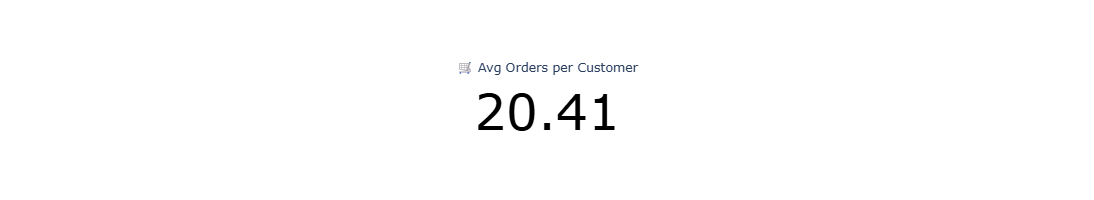

In [49]:
# 2. Customer Behavior Analysis:  

# Average number of orders per customer: 
df = run(""" select round(avg(Total_orders),2) as avg_orders_per_customer 
         from (
         select customer_id, 
         count(order_id) as Total_orders from orders_clean
         group by customer_id 
         )t""")

import plotly.graph_objects as go

avg_orders = df['avg_orders_per_customer'][0]

fig = go.Figure(go.Indicator(
    
    mode = "number",
    
    value = avg_orders,
    
    title = {"text": "🛒 Avg Orders per Customer"},
    
    number = {
        "font": {"size": 50, "color": "black"},
        "valueformat": ".2f"
    }
))

fig.update_layout(height=200)

fig.show()

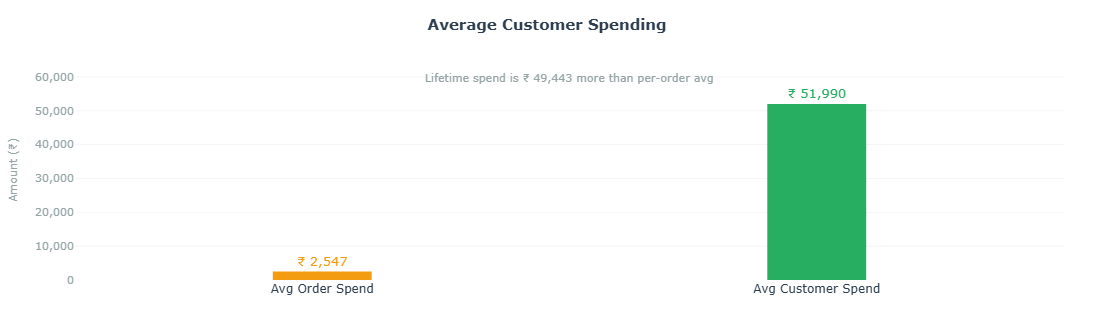

In [116]:
# Average customer spending (total & per order)

df = run(""" with order_spend_table as (
     select o.customer_id, o.order_id, sum(p.payment_value) as order_Spend
     from orders_clean o 
     join payments_clean p 
     on o.order_id = p.order_id 
     group by o.customer_id, o.order_id
     ),

     total_spend_table as (
     select customer_id, sum(order_spend) as total_spend
     from order_spend_table
     group by customer_id
     )

     SELECT 
(SELECT ROUND(AVG(order_spend),0) 
 FROM order_spend_table) AS avg_order_spend,

(SELECT ROUND(AVG(total_spend),0) 
 FROM total_spend_table) AS avg_customer_spending
""")

import plotly.graph_objects as go

avg_order    = float(df['avg_order_spend'].values[0])
avg_customer = float(df['avg_customer_spending'].values[0])

fig = go.Figure()

fig.add_trace(go.Bar(
    x=['Avg Order Spend', 'Avg Customer Spend'],
    y=[avg_order, avg_customer],
    marker=dict(
        color=['#f39c12', '#27ae60'],
        line=dict(width=0)
    ),
    width=0.2,
    text=[f"₹ {avg_order:,.0f}", f"₹ {avg_customer:,.0f}"],
    textposition='outside',
    textfont=dict(size=13, color=['#f39c12', '#27ae60']),
    hovertemplate="<b>%{x}</b><br>Amount: <b>₹ %{y:,.0f}</b><extra></extra>"
))

fig.update_layout(
    title=dict(
        text="<b>Average Customer Spending</b>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(showgrid=False, zeroline=False, tickfont=dict(size=12, color='#2c3e50')),
    yaxis=dict(
        title=dict(text='Amount (₹)', font=dict(size=11, color='#95a5a6')),
        gridcolor='#f5f5f5', zeroline=False,
        tickfont=dict(size=11, color='#95a5a6'),
        tickformat=',',
        range=[0, max(avg_order, avg_customer) * 1.25]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=330,
    margin=dict(t=60, b=50, l=60, r=30)
)

diff = round(avg_customer - avg_order, 0)
fig.add_annotation(
    x=0.5, xref='paper',
    y=max(avg_order, avg_customer) * 1.15,
    text=f"<span style='color:#95a5a6;font-size:11px'>Lifetime spend is ₹ {diff:,.0f} more than per-order avg</span>",
    showarrow=False,
    font=dict(size=11, color='#95a5a6')
)

fig.show()

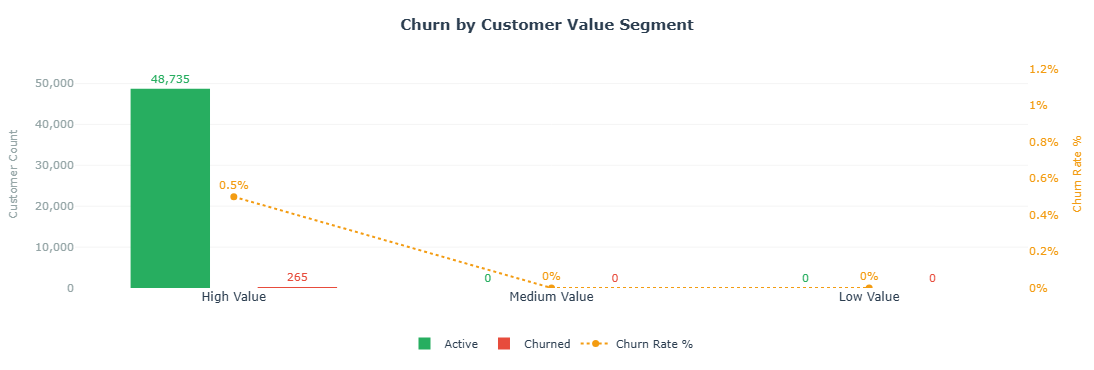

In [140]:
# Comparison of high-value, Medium- value  and  low-value customers in terms of churn:
# High Value (≥2000), Medium Value (1000–1999), Low Value (<1000)

df = run(""" with order_spend_table as (
    select o.customer_id, o.order_id, sum(p.payment_value) as order_spend
    from orders_clean o 
    join payments_clean p 
    on o.order_id = p.order_id 
    group by o.customer_id, o.order_id), 

    customer_spend_table as (
    select customer_id, sum(order_spend) as total_spend 
    from order_spend_table
    group by customer_id), 

    max_date_table as (
    select max(order_purchase_timestamp) as max_date 
    from orders_clean), 

    last_order_date as (
    select customer_id, max(order_purchase_timestamp) as last_order
    from orders_clean
    group by customer_id), 

    churn_table as (
    select l.customer_id, 
    case 
        when last_order is null or last_order < ((select max_date from max_date_table) - interval '180 days')
        then 'churned'
        else 'active'
     end as churn_status
     from last_order_date l)

    select 
      case  
        when total_spend >= 2000 then 'High_Value_Customer' 
        when total_spend >= 1000 then 'Medium_Value_Customer'
        else 'Low_Value_Customer'
     end as customer_segment, 

    churn_status, 
    count(*) as customer_count 
   from customer_spend_table c 
   join churn_table ch 
   on c.customer_id = ch.customer_id 
   group by customer_segment, churn_status
   order by customer_segment""")

import plotly.graph_objects as go

segment_order  = ['High_Value_Customer', 'Medium_Value_Customer', 'Low_Value_Customer']
segment_labels = ['High Value', 'Medium Value', 'Low Value']

def get_count(segment, status):
    val = df[(df['customer_segment'] == segment) & (df['churn_status'] == status)]['customer_count']
    return int(val.values[0]) if len(val) > 0 else 0

active_counts  = [get_count(s, 'active')  for s in segment_order]
churned_counts = [get_count(s, 'churned') for s in segment_order]

churn_rates = [
    round(churned_counts[i] / (active_counts[i] + churned_counts[i]) * 100, 1)
    if (active_counts[i] + churned_counts[i]) > 0 else 0
    for i in range(3)
]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=segment_labels,
    y=active_counts,
    name='Active',
    marker=dict(color='#27ae60', line=dict(width=0)),
    width=0.25,
    text=[f"{v:,}" for v in active_counts],
    textposition='outside',
    textfont=dict(size=11, color='#27ae60'),
    hovertemplate="<b>%{x} — Active</b><br>Count: <b>%{y:,}</b><extra></extra>"
))

fig.add_trace(go.Bar(
    x=segment_labels,
    y=churned_counts,
    name='Churned',
    marker=dict(color='#e74c3c', line=dict(width=0)),
    width=0.25,
    text=[f"{v:,}" for v in churned_counts],
    textposition='outside',
    textfont=dict(size=11, color='#e74c3c'),
    hovertemplate="<b>%{x} — Churned</b><br>Count: <b>%{y:,}</b><extra></extra>"
))

fig.add_trace(go.Scatter(
    x=segment_labels,
    y=churn_rates,
    name='Churn Rate %',
    yaxis='y2',
    mode='lines+markers+text',
    line=dict(color='#f39c12', width=2, dash='dot'),
    marker=dict(size=7, color='#f39c12'),
    text=[f"{r}%" for r in churn_rates],
    textposition='top center',
    textfont=dict(size=11, color='#f39c12'),
    hovertemplate="<b>%{x}</b><br>Churn Rate: <b>%{y}%</b><extra></extra>"
))

fig.update_layout(
    title=dict(
        text="<b>Churn by Customer Value Segment</b>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(showgrid=False, zeroline=False, tickfont=dict(size=12, color='#2c3e50')),
    yaxis=dict(
        title=dict(text='Customer Count', font=dict(size=11, color='#95a5a6')),
        gridcolor='#f5f5f5', zeroline=False,
        tickfont=dict(size=11, color='#95a5a6'),
        tickformat=','
    ),
    yaxis2=dict(
        overlaying='y', side='right',
        title=dict(text='Churn Rate %', font=dict(size=11, color='#f39c12')),
        tickfont=dict(size=11, color='#f39c12'),
        ticksuffix='%', showgrid=False,
        range=[0, max(churn_rates) * 2.5]
    ),
    barmode='group',
    bargroupgap=0.15,
    legend=dict(orientation='h', y=-0.18, x=0.5, xanchor='center',
                font=dict(size=11, color='#2c3e50')),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=370,
    margin=dict(t=60, b=60, l=60, r=55)
)

fig.show()

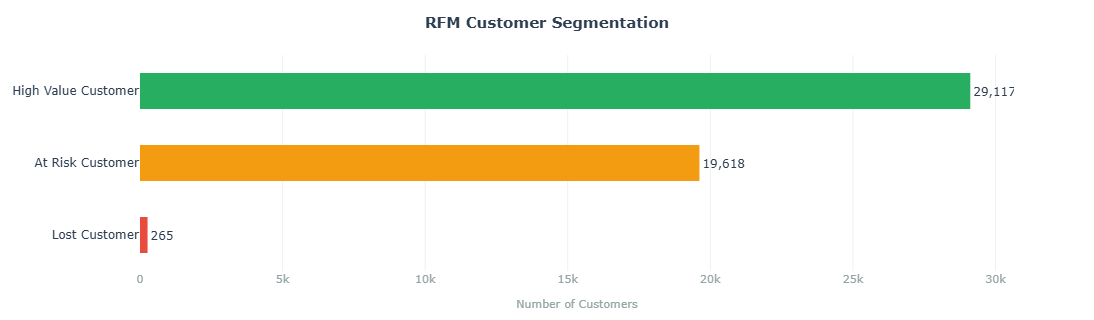

In [142]:
#  3. RFM Segmentation (Customer Value Analysis)

# Segment customers based on:

  # Recency (last purchase)
  # Frequency (number of orders)
  # Monetary (total spend)

# Identify customers based on RFM metrics using the following criteria:

   # High-Value Customers → Recency ≤ 30 days AND Frequency ≥ 5 orders AND Monetary ≥ 2000
   # At-Risk Customers → Recency > 30 days AND Recency ≤ 180 days
   # Lost Customers → Recency > 180 days

df = run("""
with order_spend_table as (
    select 
        o.customer_id,
        o.order_id,
        sum(p.payment_value) as order_spend
    from orders_clean o
    join payments_clean p
    on o.order_id = p.order_id
    group by o.customer_id, o.order_id
),
customer_spend_table as (
    select 
        customer_id,
        sum(order_spend) as monetary
    from order_spend_table
    group by customer_id
),
frequency_table as (
    select 
        customer_id,
        count(order_id) as frequency
    from orders_clean
    group by customer_id
),
recency_table as (
    select 
        customer_id,
        max(order_purchase_timestamp) as last_order
    from orders_clean
    group by customer_id
),
max_date_table as (
    select 
        max(order_purchase_timestamp) as max_date
    from orders_clean
),
rfm_table as (
select 
    r.customer_id,
    
    (select max_date from max_date_table) - r.last_order as recency_days,
    
    f.frequency,
    
    c.monetary
from recency_table r
join frequency_table f
on r.customer_id = f.customer_id
join customer_spend_table c
on r.customer_id = c.customer_id
)
select *,
case 
when recency_days <= 30 
and frequency >= 5 
and monetary >= 2000
then 'High Value Customer'
when recency_days > 30 
and recency_days <= 180
then 'At Risk Customer'
when recency_days > 180
then 'Lost Customer'
else 'Other'
end as customer_segment
from rfm_table
""")

import plotly.graph_objects as go

segment_df = df['customer_segment'].value_counts().reset_index()
segment_df.columns = ['Customer Segment', 'Count']

colors = {
    'High Value Customer': '#27ae60',
    'At Risk Customer':    '#f39c12',
    'Lost Customer':       '#e74c3c',
    'Other':               '#95a5a6'
}

segment_df = segment_df.sort_values('Count', ascending=True)

fig = go.Figure(go.Bar(
    x=segment_df['Count'],
    y=segment_df['Customer Segment'],
    orientation='h',
    marker=dict(
        color=[colors.get(s, '#95a5a6') for s in segment_df['Customer Segment']],
        line=dict(width=0)
    ),
    text=[f"{c:,}" for c in segment_df['Count']],
    textposition='outside',
    textfont=dict(size=12, color='#2c3e50'),
    hovertemplate="<b>%{y}</b><br>Customers: <b>%{x:,}</b><extra></extra>",
    width=0.5
))

fig.update_layout(
    title=dict(
        text="<b>RFM Customer Segmentation</b>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Number of Customers', font=dict(size=11, color='#95a5a6')),
        tickfont=dict(size=11, color='#95a5a6'),
        gridcolor='#f0f0f0', zeroline=False, showgrid=True
    ),
    yaxis=dict(
        tickfont=dict(size=12, color='#2c3e50'),
        showgrid=False, zeroline=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=320,
    margin=dict(t=55, b=45, l=140, r=80),
    showlegend=False
)

fig.show()

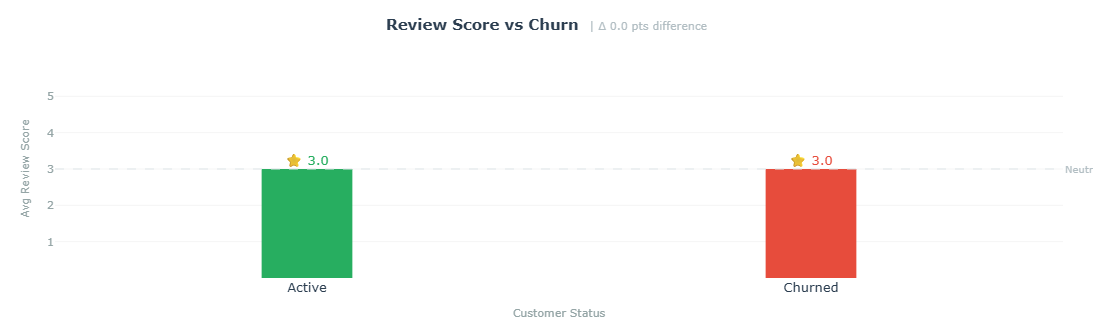

In [124]:
# 4. Customer Experience Impact: 

   # Impact of review scores on customer churn:

df = run("""WITH last_order_table AS (
    SELECT 
        customer_id,
        MAX(order_purchase_timestamp) AS last_order
    FROM orders_clean
    GROUP BY customer_id
),

max_date_table AS (
    SELECT MAX(order_purchase_timestamp) AS max_date
    FROM orders_clean
),

churn_table AS (
    SELECT 
        l.customer_id,
        CASE 
            WHEN l.last_order < (SELECT max_date FROM max_date_table) - INTERVAL '180 days'
            THEN 'Churned'
            ELSE 'Active'
        END AS churn_status
    FROM last_order_table l
),

review_avg_table AS (
    SELECT 
        o.customer_id,
        AVG(r.review_score::numeric) AS avg_review_score
    FROM reviews_clean r
    JOIN orders_clean o
    ON r.order_id = o.order_id
    GROUP BY o.customer_id
)

SELECT 
    c.churn_status,
     ROUND(AVG(r.avg_review_score),2) AS avg_review_score,
    COUNT(*) AS customer_count
FROM churn_table c
LEFT JOIN review_avg_table r
ON c.customer_id = r.customer_id
GROUP BY c.churn_status
ORDER BY c.churn_status""")

import plotly.graph_objects as go

colors = {'Active': '#27ae60', 'Churned': '#e74c3c'}

fig = go.Figure()

for _, row in df.iterrows():
    fig.add_trace(go.Bar(
        x=[row['churn_status']],
        y=[row['avg_review_score']],
        name=row['churn_status'],
        marker=dict(color=colors.get(row['churn_status']), line=dict(width=0)),
        width=0.18,
        customdata=[[row['customer_count']]],
        hovertemplate="<b>%{x}</b><br>Avg Score: <b>%{y}</b><br>Customers: <b>%{customdata[0]:,}</b><extra></extra>"
    ))

diff = round(abs(df['avg_review_score'].diff().iloc[-1]), 2)

fig.update_layout(
    title=dict(
        text=f"<b>Review Score vs Churn</b>  <span style='font-size:11px;color:#b2bec3'>| Δ {diff} pts difference</span>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        showgrid=False, zeroline=False,
        tickfont=dict(size=13, color='#2c3e50'),
        title=dict(text='Customer Status', font=dict(size=11, color='#95a5a6'))
    ),
    yaxis=dict(
        range=[0, 6],
        tickvals=[1, 2, 3, 4, 5],
        gridcolor='#f5f5f5',
        tickfont=dict(size=11, color='#95a5a6'),
        zeroline=False,
        title=dict(text='Avg Review Score', font=dict(size=11, color='#95a5a6'))
    ),
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=330,
    margin=dict(t=60, b=50, l=55, r=30)
)

fig.add_hline(
    y=3, line_dash='dash', line_color='#dfe6e9', line_width=1,
    annotation_text="Neutral 3.0",
    annotation_position="right",
    annotation_font=dict(size=10, color='#b2bec3')
)

# Score upar bar ke
for _, row in df.iterrows():
    fig.add_annotation(
        x=row['churn_status'],
        y=row['avg_review_score'] + 0.25,
        text=f"⭐ {row['avg_review_score']}",
        showarrow=False,
        font=dict(size=13, color=colors.get(row['churn_status']))
    )

fig.show()

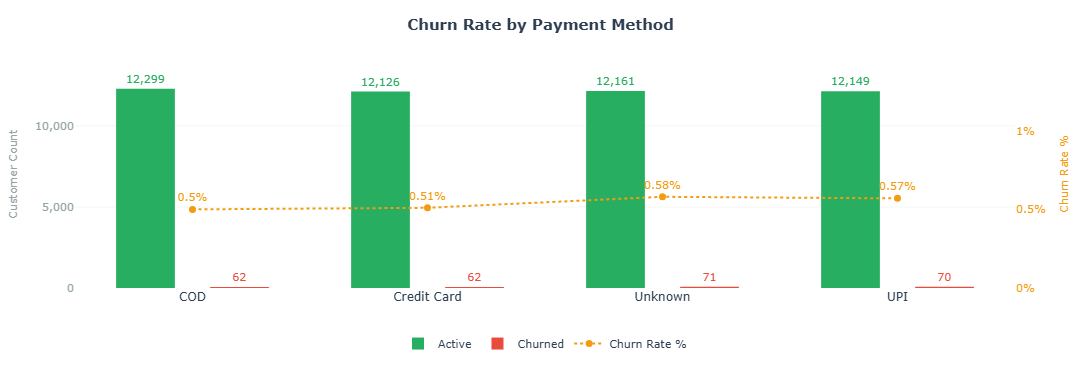

In [108]:
# 5. Payment Behavior Analysis

    # Churn rate by payment method (COD vs Online)

df = run("""WITH last_order_table AS (
    SELECT 
        customer_id,
        MAX(order_purchase_timestamp) AS last_order
    FROM orders_clean
    GROUP BY customer_id
),
max_date_table AS (
    SELECT MAX(order_purchase_timestamp) AS max_date
    FROM orders_clean
),
churn_table AS (
    SELECT 
        l.customer_id,
        CASE 
            WHEN l.last_order IS NULL OR
                 l.last_order < (SELECT max_date FROM max_date_table) 
                                 - INTERVAL '180 days'
            THEN 'Churned'
            ELSE 'Active'
        END AS churn_status
    FROM last_order_table l
),
last_payment_table AS (
    SELECT customer_id, payment_type
    FROM (
        SELECT 
            o.customer_id,
            p.payment_type,
            ROW_NUMBER() OVER (
                PARTITION BY o.customer_id 
                ORDER BY p.payment_value DESC
            ) AS rn
        FROM orders_clean o
        JOIN last_order_table l
            ON o.customer_id = l.customer_id
            AND o.order_purchase_timestamp = l.last_order
        JOIN payments_clean p 
            ON o.order_id = p.order_id
    ) sub
    WHERE rn = 1
)
SELECT 
    lpt.payment_type,
    c.churn_status,
    COUNT(DISTINCT c.customer_id) AS customer_count
FROM churn_table c
JOIN last_payment_table lpt 
    ON c.customer_id = lpt.customer_id
GROUP BY lpt.payment_type, c.churn_status
ORDER BY lpt.payment_type, c.churn_status""")

import plotly.graph_objects as go

methods = df['payment_type'].unique()
active  = df[df['churn_status']=='Active'].set_index('payment_type')['customer_count']
churned = df[df['churn_status']=='Churned'].set_index('payment_type')['customer_count']
churn_rate = (churned / (active + churned) * 100).round(2)

colors_active  = '#27ae60'
colors_churned = '#e74c3c'

fig = go.Figure()

fig.add_trace(go.Bar(
    x=list(methods),
    y=[active.get(m, 0) for m in methods],
    name='Active',
    marker=dict(color=colors_active, line=dict(width=0)),
    width=0.25,
    text=[f"{active.get(m, 0):,}" for m in methods],
    textposition='outside',
    textfont=dict(size=11, color=colors_active),
    hovertemplate="<b>%{x} — Active</b><br>Count: <b>%{y:,}</b><extra></extra>"
))

fig.add_trace(go.Bar(
    x=list(methods),
    y=[churned.get(m, 0) for m in methods],
    name='Churned',
    marker=dict(color=colors_churned, line=dict(width=0)),
    width=0.25,
    text=[f"{churned.get(m, 0):,}" for m in methods],
    textposition='outside',
    textfont=dict(size=11, color=colors_churned),
    hovertemplate="<b>%{x} — Churned</b><br>Count: <b>%{y:,}</b><extra></extra>"
))

fig.add_trace(go.Scatter(
    x=list(methods),
    y=[churn_rate.get(m, 0) for m in methods],
    name='Churn Rate %',
    yaxis='y2',
    mode='lines+markers+text',
    line=dict(color='#f39c12', width=2, dash='dot'),
    marker=dict(size=7, color='#f39c12'),
    text=[f"{churn_rate.get(m, 0)}%" for m in methods],
    textposition='top center',
    textfont=dict(size=11, color='#f39c12'),
    hovertemplate="<b>%{x}</b><br>Churn Rate: <b>%{y}%</b><extra></extra>"
))

fig.update_layout(
    title=dict(
        text="<b>Churn Rate by Payment Method</b>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(showgrid=False, zeroline=False, tickfont=dict(size=12, color='#2c3e50')),
    yaxis=dict(
        title=dict(text='Customer Count', font=dict(size=11, color='#95a5a6')),
        gridcolor='#f5f5f5', zeroline=False,
        tickfont=dict(size=11, color='#95a5a6'),
        tickformat=','
    ),
    yaxis2=dict(
        overlaying='y', side='right',
        title=dict(text='Churn Rate %', font=dict(size=11, color='#f39c12')),
        tickfont=dict(size=11, color='#f39c12'),
        ticksuffix='%', showgrid=False,
        range=[0, max(churn_rate) * 2.5]
    ),
    barmode='group',
    bargroupgap=0.15,
    legend=dict(orientation='h', y=-0.18, x=0.5, xanchor='center',
                font=dict(size=11, color='#2c3e50')),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=370,
    margin=dict(t=60, b=60, l=60, r=55)
)

fig.show()

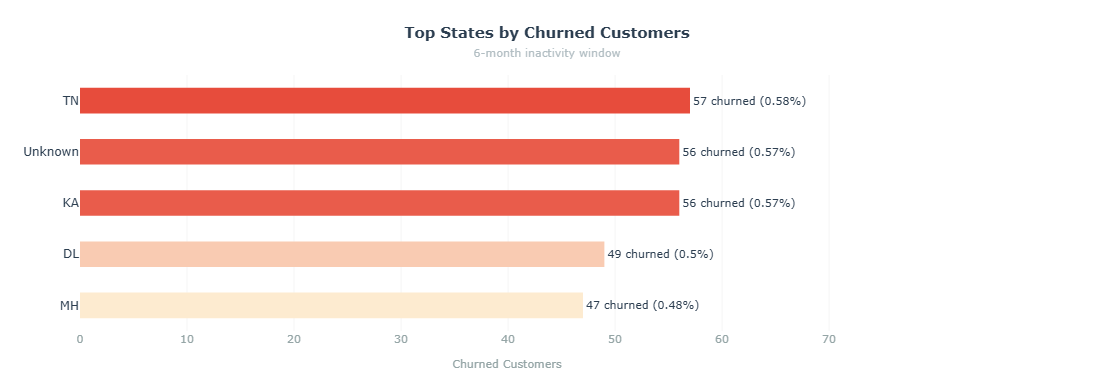

In [112]:
#️  6. Geographic Analysis

# Top states with highest churn rate:

df = run("""
WITH max_date_table AS (
    SELECT MAX(order_purchase_timestamp) AS max_date
    FROM orders_clean
),
last_order_table AS (
    SELECT 
        customer_id,
        MAX(order_purchase_timestamp) AS last_order
    FROM orders_clean
    GROUP BY customer_id
),
churn_table AS (
    SELECT 
        l.customer_id,
        CASE 
            WHEN l.last_order IS NULL OR
                 l.last_order < ((SELECT max_date FROM max_date_table) - INTERVAL '180 days')
            THEN 1 ELSE 0
        END AS is_churn
    FROM last_order_table l
),
customer_state_table AS (
    SELECT DISTINCT ON (o.customer_id)
        o.customer_id,
        c.customer_state
    FROM orders_clean o
    JOIN customers_clean c ON o.customer_id = c.customer_id
    ORDER BY o.customer_id, o.order_purchase_timestamp DESC
)
SELECT 
    cs.customer_state,
    COUNT(DISTINCT c.customer_id) AS total_customers,
    SUM(c.is_churn) AS churned_customers,
    ROUND(100.0 * SUM(c.is_churn) / COUNT(*), 2) AS churn_rate
FROM churn_table c
JOIN customer_state_table cs ON c.customer_id = cs.customer_id
GROUP BY cs.customer_state
ORDER BY churned_customers DESC
LIMIT 10
""")

import plotly.graph_objects as go

df = df.sort_values('churned_customers', ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df['churned_customers'],
    y=df['customer_state'],
    orientation='h',
    marker=dict(
        color=df['churned_customers'],
        colorscale=[[0, '#fdebd0'], [1, '#e74c3c']],
        line=dict(width=0)
    ),
    width=0.5,
    text=[f"{c} churned ({r}%)" for c, r in zip(df['churned_customers'], df['churn_rate'])],
    textposition='outside',
    textfont=dict(size=11, color='#2c3e50'),
    hovertemplate="<b>%{y}</b><br>Churned: <b>%{x}</b><br>Total: <b>%{customdata:,}</b><extra></extra>",
    customdata=df['total_customers']
))

fig.update_layout(
    title=dict(
        text="<b>Top States by Churned Customers</b><br><span style='font-size:11px;color:#b2bec3'>6-month inactivity window</span>",
        font=dict(size=15, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Churned Customers', font=dict(size=11, color='#95a5a6')),
        tickfont=dict(size=11, color='#95a5a6'),
        gridcolor='#f5f5f5',
        zeroline=False,
        range=[0, df['churned_customers'].max() * 1.4]
    ),
    yaxis=dict(
        tickfont=dict(size=12, color='#2c3e50'),
        showgrid=False,
        zeroline=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=380,
    margin=dict(t=75, b=45, l=80, r=160)
)

fig.show()